# Loan Default Risk — Supervised Classification with Fairness Evaluation

**Author:** Adwoa Nyame

---

## Outline

1. Imports and Configuration
2. Helper Functions
3. Data Loading and Cleaning
4. Exploratory Data Analysis
5. Feature Selection
6. Feature Engineering and Train/Val/Test Split
7. Preprocessing
8. Logistic Regression (Baseline)
9. XGBoost with Optuna Tuning
10. Neural Network (MLP)
11. Calibration Evaluation
12. Threshold Optimization
13. Fairness Evaluation
14. Analysis Summary

---
## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    precision_recall_curve, roc_curve, auc,
)

import xgboost as xgb
import optuna
import shap

from fairlearn.metrics import (
    MetricFrame, false_positive_rate,
    true_positive_rate, selection_rate,
)
from sklearn.metrics import accuracy_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs('../data/processed',  exist_ok=True)
os.makedirs('../data/splits',     exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

---
## 2. Helper Functions

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────

CANDIDATE_COLS = [
    'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mort_acc', 'pub_rec_bankruptcies',
    'loan_status', 'issue_d',
]
GOOD_STATUS = {'Fully Paid'}
BAD_STATUS  = {'Charged Off', 'Default'}


def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, usecols=CANDIDATE_COLS)

    # Target: keep only resolved loans, drop in-progress
    mask = df['loan_status'].isin(GOOD_STATUS | BAD_STATUS)
    df   = df[mask].copy()
    df['target'] = df['loan_status'].isin(BAD_STATUS).astype(int)
    df = df.drop(columns=['loan_status'])

    # FIX: str.extract returns a DataFrame; select column [0] before casting
    df['term'] = df['term'].str.strip().str.extract(r'(\d+)')[0].astype(int)

    df['emp_length'] = df['emp_length'].str.extract(r'(\d+)')[0].astype(float)
    df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

    # Collapse fico range to midpoint
    df['fico'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    df = df.drop(columns=['fico_range_low', 'fico_range_high'])

    df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)
    df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

    # Cap annual_inc at 99th percentile before imputing
    cap = df['annual_inc'].quantile(0.99)
    df['annual_inc'] = df['annual_inc'].clip(upper=cap).fillna(df['annual_inc'].median())

    df['dti']                  = df['dti'].fillna(df['dti'].median())
    df['mort_acc']             = df['mort_acc'].fillna(0)
    df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

    df['issue_year'] = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.year
    df = df.drop(columns=['issue_d'])

    return df


def temporal_split(df):
    train = df[df['issue_year'] < 2016].drop(columns=['issue_year'])
    val   = df[df['issue_year'] == 2016].drop(columns=['issue_year'])
    test  = df[df['issue_year'] >= 2017].drop(columns=['issue_year'])
    for name, s in [('Train', train), ('Val', val), ('Test', test)]:
        print(f'{name}: {len(s):,} rows  |  default rate: {s["target"].mean():.1%}')
    return train, val, test


def engineer_features(df):
    df = df.copy()
    df['loan_to_income']  = df['loan_amnt'] / (df['annual_inc'] + 1)
    df['install_to_inc']  = (df['loan_amnt'] * df['int_rate'] / 1200) / (df['annual_inc'] / 12 + 1)
    df['fico_band']       = pd.cut(df['fico'], bins=[0,620,660,700,740,780,900], labels=False)
    df['high_dti']        = (df['dti'] > 20).astype(int)
    df['any_pub_rec']     = (df['pub_rec'] > 0).astype(int)
    return df


# ── Evaluation ────────────────────────────────────────────────────────────────

def evaluate(y_true, y_prob, threshold=0.5, model_name='model'):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'model':     model_name,
        'threshold': threshold,
        'roc_auc':   round(roc_auc_score(y_true, y_prob), 4),
        'pr_auc':    round(average_precision_score(y_true, y_prob), 4),
        'brier':     round(brier_score_loss(y_true, y_prob), 4),
        'f1':        round(f1_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
    }


def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n   = len(y_true)
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return round(float(ece), 4)


def threshold_sweep(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return pd.DataFrame({
        'threshold': np.append(thresholds, 1.0),
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
    })


def find_operating_points(sweep_df):
    f1_row   = sweep_df.loc[sweep_df['f1'].idxmax()]
    cons_df  = sweep_df[sweep_df['precision'] >= 0.80]
    cons_row = cons_df.loc[cons_df['recall'].idxmax()] if len(cons_df) else f1_row
    return {'F1-optimal': f1_row, 'Conservative': cons_row}


# ── Neural network ────────────────────────────────────────────────────────────

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(1)


class TemperatureScaler(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1))
    def forward(self, x):
        return self.model(x) / self.temperature


def train_mlp(X_train, y_train, X_val, y_val,
              hidden_dims=(256, 128, 64), dropout=0.3,
              lr=1e-3, batch_size=512, epochs=50, patience=5):
    device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tr       = torch.tensor(X_train, dtype=torch.float32)
    y_tr       = torch.tensor(y_train, dtype=torch.float32)
    X_v        = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_v        = torch.tensor(y_val,   dtype=torch.float32).to(device)
    pos_weight = torch.tensor([(y_train==0).sum()/(y_train==1).sum()], dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loader     = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    model      = MLP(X_train.shape[1], hidden_dims, dropout).to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
    best_val_loss, best_state, no_improve = float('inf'), None, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_v), y_v).item()
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    model.load_state_dict(best_state)
    return model, device


def calibrate_temperature(model, X_val, y_val, device):
    scaled    = TemperatureScaler(model).to(device)
    X_v       = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_v       = torch.tensor(y_val, dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.LBFGS([scaled.temperature], lr=0.01, max_iter=100)
    # FIX: compute loss once per closure call to avoid double forward pass and inconsistent gradients
    def closure():
        optimizer.zero_grad()
        loss = criterion(scaled(X_v), y_v)
        loss.backward()
        return loss
    optimizer.step(closure)
    print(f'Optimal temperature: {scaled.temperature.item():.4f}')
    return scaled


def nn_predict_proba(model, X, device):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy()
    return 1 / (1 + np.exp(-logits))

---
## 3. Data Loading and Cleaning

In [3]:
RAW_PATH = '../data/raw/accepted_2007_to_2018Q4.csv.gz'

df = load_and_clean(RAW_PATH)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Default rate: {df["target"].mean():.1%}')
df.head(3)

Rows: 1,345,350  |  Columns: 21
Default rate: 20.0%


,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,target,fico,issue_year
0,3600.0,36,13.99,C,C4,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,...,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,0,677.0,2015
1,24700.0,36,11.99,C,C1,10.0,MORTGAGE,65000.0,Not Verified,small_business,...,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,0,717.0,2015
2,20000.0,60,10.78,B,B4,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,...,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,0,697.0,2015


In [4]:
df.to_parquet('../data/processed/loans_clean.parquet', index=False)
df.to_csv('../data/processed/loans_clean.csv', index=False)

---
## 4. Exploratory Data Analysis

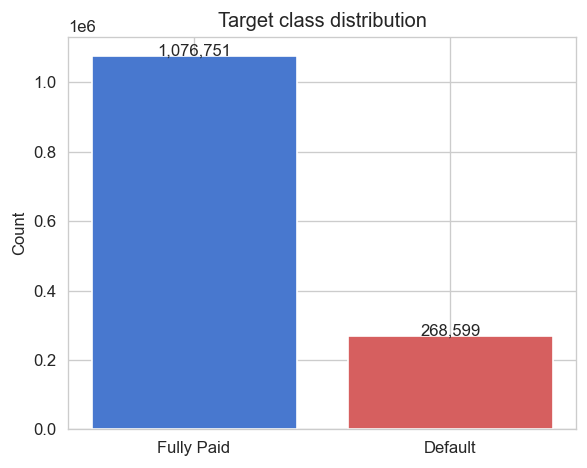

In [5]:
# Target distribution
counts = df['target'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Fully Paid', 'Default'], counts.values, color=['#4878CF', '#D65F5F'])
ax.set_ylabel('Count')
ax.set_title('Target class distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/eda_target.png', dpi=150, bbox_inches='tight')
plt.show()

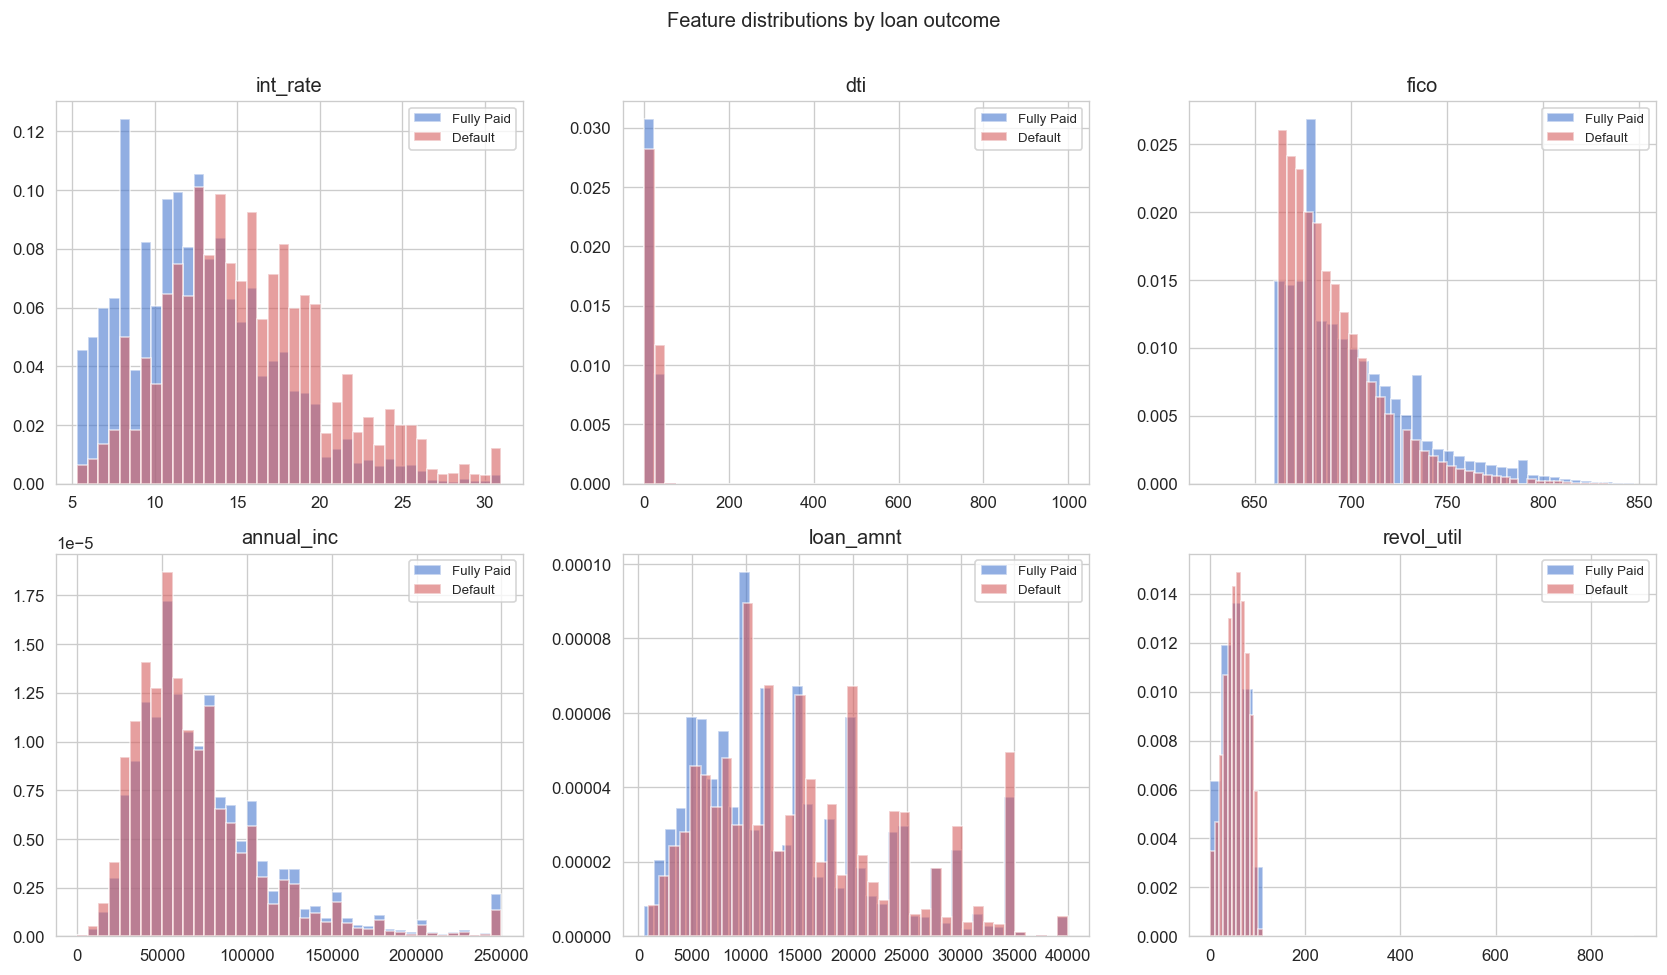

In [6]:
# Feature distributions by outcome
# Note: grade is still a string here (A-G). EDA runs before encoding in section 6.
numeric_cols = ['int_rate', 'dti', 'fico', 'annual_inc', 'loan_amnt', 'revol_util']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    for label, grp in df.groupby('target'):
        color = '#D65F5F' if label == 1 else '#4878CF'
        name  = 'Default' if label == 1 else 'Fully Paid'
        grp[col].hist(ax=axes[i], bins=40, alpha=0.6, label=name, density=True, color=color)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
plt.suptitle('Feature distributions by loan outcome', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

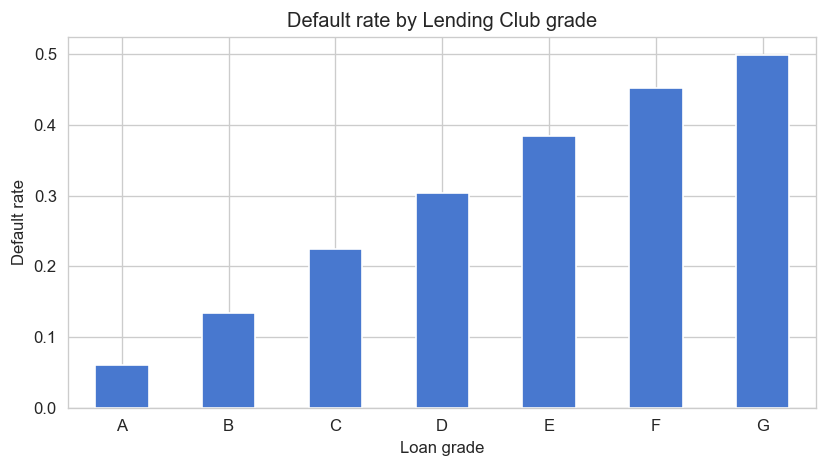

In [7]:
# Default rate by grade — use raw string grade before encoding
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_rates = df.groupby('grade')['target'].mean().reindex(grade_order)

fig, ax = plt.subplots(figsize=(7, 4))
grade_rates.plot.bar(ax=ax, color='#4878CF')
ax.set_ylabel('Default rate')
ax.set_xlabel('Loan grade')
ax.set_title('Default rate by Lending Club grade')
ax.set_xticklabels(grade_order, rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/eda_default_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

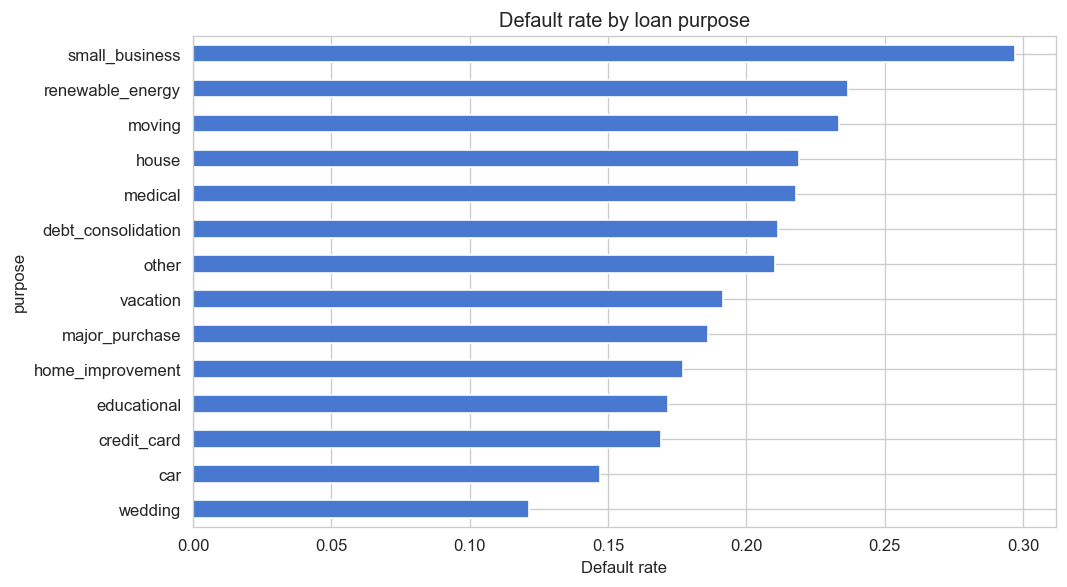

In [8]:
# Default rate by purpose
purpose_rates = df.groupby('purpose')['target'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
purpose_rates.plot.barh(ax=ax, color='#4878CF')
ax.set_xlabel('Default rate')
ax.set_title('Default rate by loan purpose')
plt.tight_layout()
plt.savefig('../reports/figures/eda_default_by_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

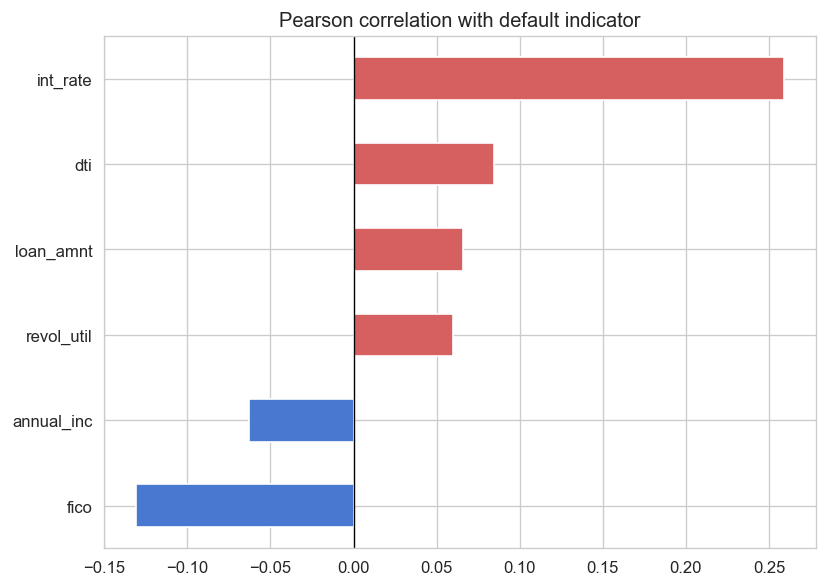

In [9]:
# Correlation with target
corr = df[numeric_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot.barh(ax=ax, color=['#D65F5F' if v > 0 else '#4878CF' for v in corr])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pearson correlation with default indicator')
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

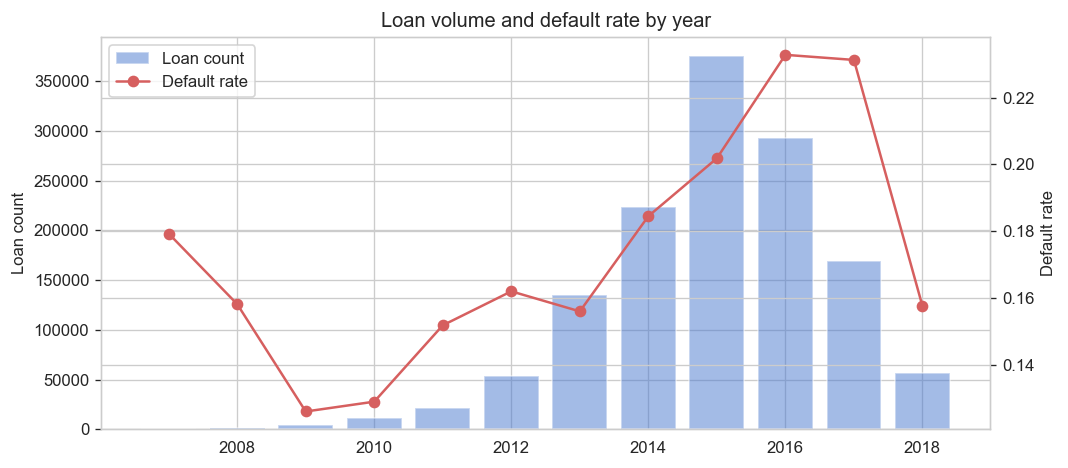

In [10]:
# Loan volume and default rate over time
yearly = df.groupby('issue_year').agg(
    loan_count=('target', 'count'),
    default_rate=('target', 'mean')
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(yearly.index, yearly['loan_count'], alpha=0.5, color='#4878CF', label='Loan count')
ax2.plot(yearly.index, yearly['default_rate'], color='#D65F5F', marker='o', label='Default rate')
ax1.set_ylabel('Loan count')
ax2.set_ylabel('Default rate')
ax1.set_title('Loan volume and default rate by year')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../reports/figures/eda_volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Feature Selection

This section documents and executes a four-step data-driven process for selecting the final modeling features.
All filters are applied using the full dataset at this stage; when filters require correlation with the target,
they will be re-confirmed on the training split only after the temporal split is made in section 6.

**Step 1 — Leakage audit:** identify and exclude any field known only after loan origination.  
**Step 2 — Missingness filter:** drop columns missing more than 40% of values.  
**Step 3 — Near-zero variance filter:** drop columns where one value accounts for more than 99% of rows.  
**Step 4 — Redundancy check:** identify near-collinear numeric pairs; keep the one with higher target correlation.

In [11]:
# ── Step 1: Leakage audit ─────────────────────────────────────────────────────
# All fields in CANDIDATE_COLS were already screened for origination-time availability.
# Document the reasoning explicitly here for portfolio reviewers.

leakage_notes = {
    'loan_amnt':           ('keep',   'Requested at origination'),
    'term':                ('keep',   'Selected at origination'),
    'int_rate':            ('keep',   'Set at origination based on grade'),
    'grade':               ('keep',   'Assigned by LC at origination'),
    'sub_grade':           ('drop',   'Redundant with grade; finer-grained version of same signal'),
    'emp_length':          ('keep',   'Self-reported at application'),
    'home_ownership':      ('keep',   'Self-reported at application'),
    'annual_inc':          ('keep',   'Self-reported at application; also used for fairness grouping'),
    'verification_status': ('keep',   'LC income verification result at origination'),
    'purpose':             ('keep',   'Stated at application'),
    'dti':                 ('keep',   'Computed from application data at origination'),
    'fico':                ('keep',   'Pulled at application (midpoint of range)'),
    'open_acc':            ('keep',   'Credit bureau snapshot at application'),
    'pub_rec':             ('keep',   'Credit bureau snapshot at application'),
    'revol_bal':           ('keep',   'Credit bureau snapshot at application'),
    'revol_util':          ('keep',   'Credit bureau snapshot at application'),
    'total_acc':           ('keep',   'Credit bureau snapshot at application'),
    'mort_acc':            ('keep',   'Credit bureau snapshot at application'),
    'pub_rec_bankruptcies':('keep',   'Credit bureau snapshot at application'),
}

audit_df = pd.DataFrame.from_dict(
    leakage_notes, orient='index', columns=['decision', 'rationale']
).reset_index().rename(columns={'index': 'feature'})

print('Leakage audit:')
print(audit_df.to_string(index=False))

# sub_grade dropped here; grade kept and will be ordinally encoded in section 6
df = df.drop(columns=['sub_grade'], errors='ignore')
print(f'\nDropped sub_grade. Remaining columns: {df.shape[1]}')

Leakage audit:
             feature decision                                                     rationale
           loan_amnt     keep                                      Requested at origination
                term     keep                                       Selected at origination
            int_rate     keep                             Set at origination based on grade
               grade     keep                                 Assigned by LC at origination
           sub_grade     drop    Redundant with grade; finer-grained version of same signal
          emp_length     keep                                  Self-reported at application
      home_ownership     keep                                  Self-reported at application
          annual_inc     keep Self-reported at application; also used for fairness grouping
 verification_status     keep                  LC income verification result at origination
             purpose     keep                                    

In [12]:
# ── Step 2: Missingness filter ────────────────────────────────────────────────
MISS_THRESHOLD = 0.40

# Exclude target and issue_year from the filter
feature_cols = [c for c in df.columns if c not in ('target', 'issue_year')]
missing_rates = df[feature_cols].isnull().mean().sort_values(ascending=False)

print('Missing rate by feature:')
print(missing_rates[missing_rates > 0].round(3).to_string())

high_missing = missing_rates[missing_rates > MISS_THRESHOLD].index.tolist()
if high_missing:
    df = df.drop(columns=high_missing)
    print(f'\nDropped (>{MISS_THRESHOLD:.0%} missing): {high_missing}')
else:
    print(f'\nNo columns exceed {MISS_THRESHOLD:.0%} missing threshold after cleaning.')

Missing rate by feature:
Series([], )

No columns exceed 40% missing threshold after cleaning.


In [13]:
# ── Step 3: Near-zero variance filter ────────────────────────────────────────
NZV_THRESHOLD = 0.99

feature_cols = [c for c in df.columns if c not in ('target', 'issue_year', 'grade',
                'home_ownership', 'verification_status', 'purpose')]
nzv_dropped = []
for col in feature_cols:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > NZV_THRESHOLD:
        nzv_dropped.append((col, round(top_freq, 4)))

if nzv_dropped:
    drop_cols = [c for c, _ in nzv_dropped]
    df = df.drop(columns=drop_cols)
    print(f'Dropped (near-zero variance): {nzv_dropped}')
else:
    print('No near-zero variance columns found.')

No near-zero variance columns found.


In [14]:
# ── Step 4: Redundancy check (pairwise correlation among numeric features) ────
CORR_THRESHOLD = 0.90

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ('target', 'issue_year')]

corr_matrix = df[num_cols].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, round(upper.loc[row, col], 3))
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]

if high_corr_pairs:
    print(f'Feature pairs with |r| > {CORR_THRESHOLD}:')
    target_corr = df[num_cols + ['target']].corr()['target'].abs()
    to_drop = set()
    for f1, f2, r in high_corr_pairs:
        keep = f1 if target_corr[f1] >= target_corr[f2] else f2
        drop = f2 if keep == f1 else f1
        to_drop.add(drop)
        print(f'  {f1} vs {f2}  (r={r})  -> keep {keep}, drop {drop}')
    df = df.drop(columns=list(to_drop))
    print(f'\nDropped: {list(to_drop)}')
else:
    print(f'No feature pairs exceed |r| = {CORR_THRESHOLD}.')

No feature pairs exceed |r| = 0.9.


Final feature count: 18

Numeric features ranked by absolute correlation with target:
int_rate                0.2588
term                    0.1761
fico                    0.1307
dti                     0.0845
mort_acc                0.0694
loan_amnt               0.0656
annual_inc              0.0631
revol_util              0.0600
open_acc                0.0281
pub_rec                 0.0262
pub_rec_bankruptcies    0.0253
revol_bal               0.0200
emp_length              0.0138
total_acc               0.0113


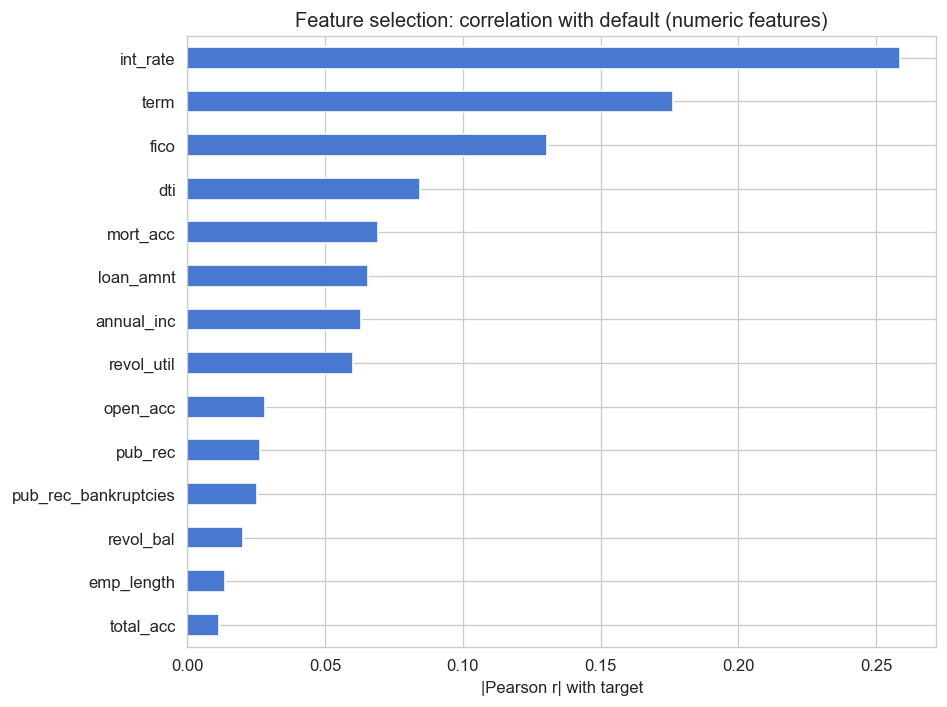

In [15]:
# ── Summary: final feature set ────────────────────────────────────────────────
final_features = [c for c in df.columns if c not in ('target', 'issue_year')]

num_cols_final = df[final_features].select_dtypes(include=[np.number]).columns.tolist()
target_corr_final = df[num_cols_final + ['target']].corr()['target'].drop('target').abs().sort_values(ascending=False)

print(f'Final feature count: {len(final_features)}')
print('\nNumeric features ranked by absolute correlation with target:')
print(target_corr_final.round(4).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
target_corr_final.sort_values().plot.barh(ax=ax, color='#4878CF')
ax.set_title('Feature selection: correlation with default (numeric features)')
ax.set_xlabel('|Pearson r| with target')
plt.tight_layout()
plt.savefig('../reports/figures/feature_selection_corr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Engineering and Train/Val/Test Split

In [16]:
df = engineer_features(df)

# One-hot encode nominal columns.
# Encoding happens before the split so all splits share the same dummy columns.
# Do not move the split above this line.
nom_cols = ['home_ownership', 'verification_status', 'purpose']
df = pd.get_dummies(df, columns=nom_cols, drop_first=True)

# Ordinal encode grade (A=0, G=6)
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
df['grade'] = df['grade'].map(grade_map)

print(f'Features after encoding: {df.shape[1]}')

train, val, test = temporal_split(df)

Features after encoding: 42
Train: 826,606 rows  |  default rate: 18.4%
Val: 293,105 rows  |  default rate: 23.3%
Test: 225,639 rows  |  default rate: 21.3%


In [17]:
for name, split in [('train', train), ('val', val), ('test', test)]:
    split.to_parquet(f'../data/splits/{name}.parquet', index=False)
    split.to_csv(f'../data/splits/{name}.csv', index=False)
print('Splits saved as parquet and CSV.')

Splits saved as parquet and CSV.


---
## 7. Preprocessing

In [18]:
TARGET = 'target'

X_train_df = train.drop(columns=[TARGET])
y_train    = train[TARGET].values
X_val_df   = val.drop(columns=[TARGET])
y_val      = val[TARGET].values
X_test_df  = test.drop(columns=[TARGET])
y_test     = test[TARGET].values

# annual_inc is extracted from the raw (unscaled) test split here for fairness grouping.
# It stays in X_test_df as a modeling feature and will be scaled by the preprocessor below.
# These are two separate uses of the same column: one for grouping, one for the model.
annual_inc_test = X_test_df['annual_inc'].values

feature_names = X_train_df.columns.tolist()

# Fit on train only; transform val and test with the same fitted parameters
preprocessor = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

X_train = preprocessor.fit_transform(X_train_df)
X_val   = preprocessor.transform(X_val_df)
X_test  = preprocessor.transform(X_test_df)

print(f'X_train: {X_train.shape}  |  positive rate: {y_train.mean():.1%}')
print(f'X_val:   {X_val.shape}  |  positive rate: {y_val.mean():.1%}')
print(f'X_test:  {X_test.shape}  |  positive rate: {y_test.mean():.1%}')

X_train: (826606, 40)  |  positive rate: 18.4%
X_val:   (293105, 40)  |  positive rate: 23.3%
X_test:  (225639, 40)  |  positive rate: 21.3%


---
## 8. Logistic Regression (Baseline)

In [19]:
# Train plain LR for coefficient extraction; wrap in isotonic calibration for final probabilities
lr_plain = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                               max_iter=1000, class_weight='balanced', random_state=SEED)
lr_plain.fit(X_train, y_train)

lr_cal = CalibratedClassifierCV(lr_plain, method='isotonic', cv=5)
lr_cal.fit(X_train, y_train)

y_prob_lr = lr_cal.predict_proba(X_test)[:, 1]
print(pd.Series(evaluate(y_test, y_prob_lr, model_name='Logistic Regression')))

model        Logistic Regression
threshold                    0.5
roc_auc                   0.6958
pr_auc                    0.3607
brier                     0.1557
f1                        0.0959
precision                 0.4978
recall                    0.0531
dtype: object


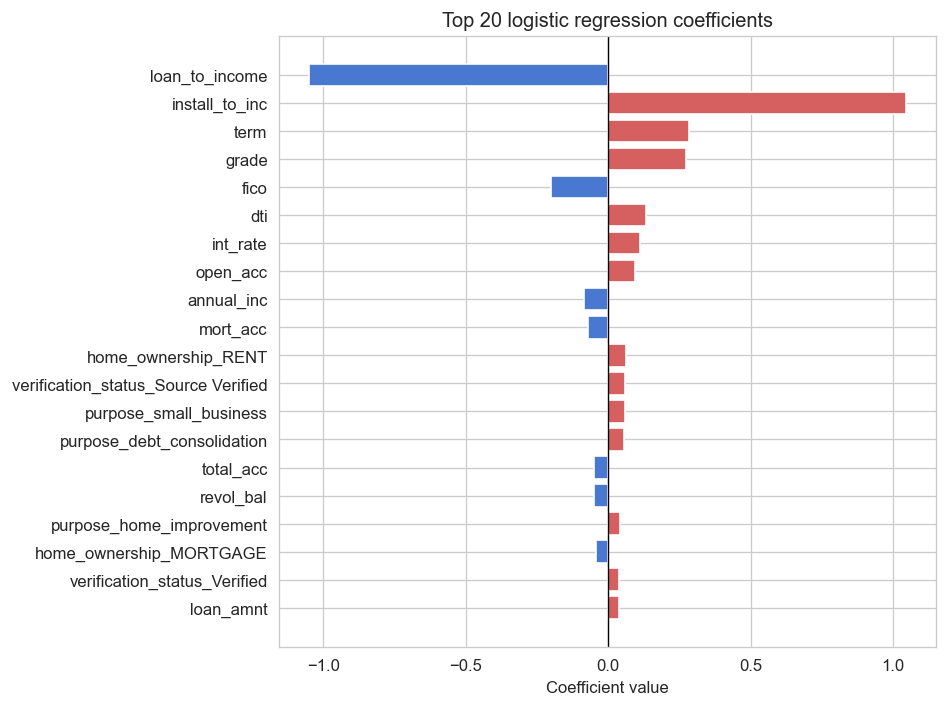

In [20]:
coef_df = (
    pd.DataFrame({'feature': feature_names, 'coef': lr_plain.coef_[0]})
    .assign(abs_coef=lambda x: x['coef'].abs())
    .sort_values('abs_coef', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#D65F5F' if v > 0 else '#4878CF' for v in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 20 logistic regression coefficients')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('../reports/figures/lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. XGBoost with Optuna Tuning

In [21]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {spw:.2f}')

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2.0),
    }
    model = xgb.XGBClassifier(
        **params, scale_pos_weight=spw,
        eval_metric='aucpr', random_state=SEED, n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'Best PR-AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

scale_pos_weight: 4.43


  0%|          | 0/50 [00:00<?, ?it/s]

Best PR-AUC: 0.4253
Best params: {'n_estimators': 492, 'max_depth': 5, 'learning_rate': 0.04958745859348774, 'subsample': 0.7534662775766362, 'colsample_bytree': 0.8113170356651835, 'min_child_weight': 4, 'reg_alpha': 0.6974211598484383, 'reg_lambda': 1.7419947570329641}


In [22]:
xgb_model = xgb.XGBClassifier(
    **study.best_params, scale_pos_weight=spw,
    eval_metric='aucpr', random_state=SEED, n_jobs=-1,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(pd.Series(evaluate(y_test, y_prob_xgb, model_name='XGBoost')))

model        XGBoost
threshold        0.5
roc_auc       0.7074
pr_auc        0.3775
brier         0.2141
f1            0.4412
precision      0.334
recall        0.6495
dtype: object


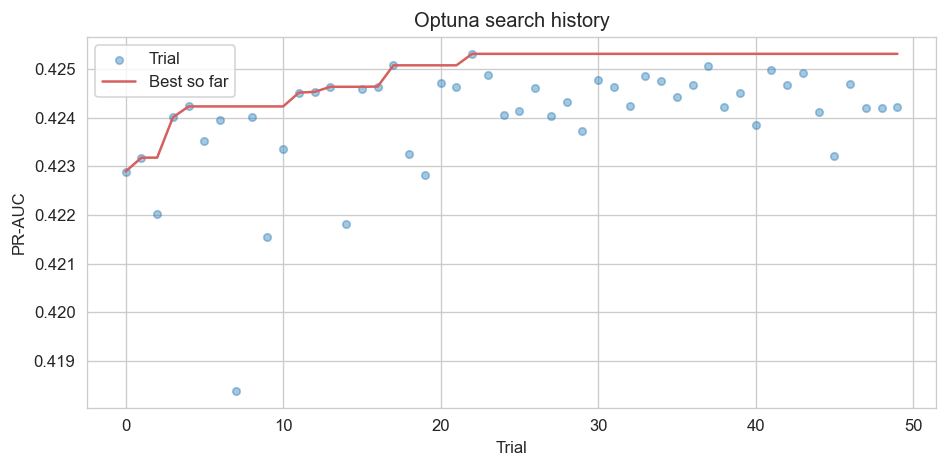

In [23]:
trial_df = study.trials_dataframe()[['number', 'value']].rename(columns={'value': 'pr_auc'})
trial_df['best_so_far'] = trial_df['pr_auc'].cummax()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(trial_df['number'], trial_df['pr_auc'], alpha=0.4, s=20, label='Trial')
ax.plot(trial_df['number'], trial_df['best_so_far'], color='#D65F5F', lw=1.5, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('PR-AUC')
ax.set_title('Optuna search history')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/xgb_optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()

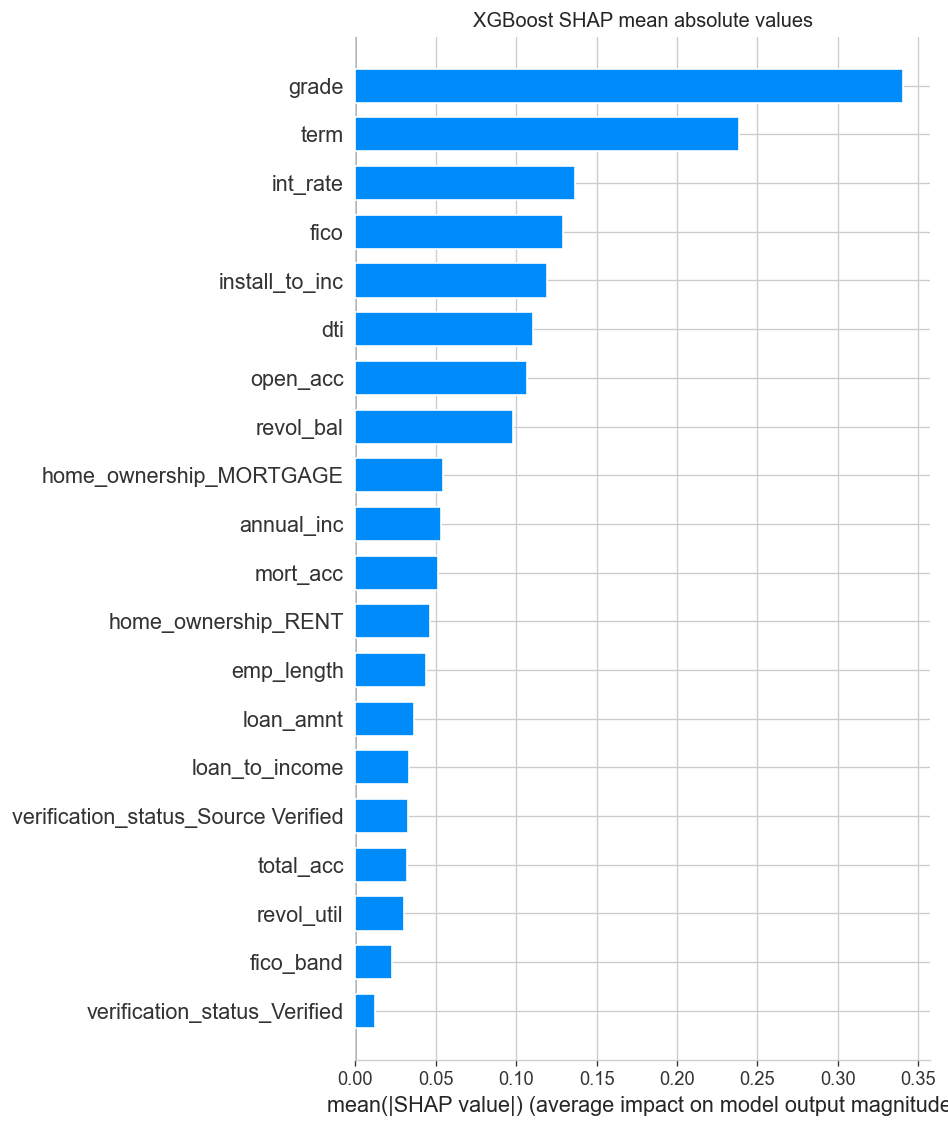

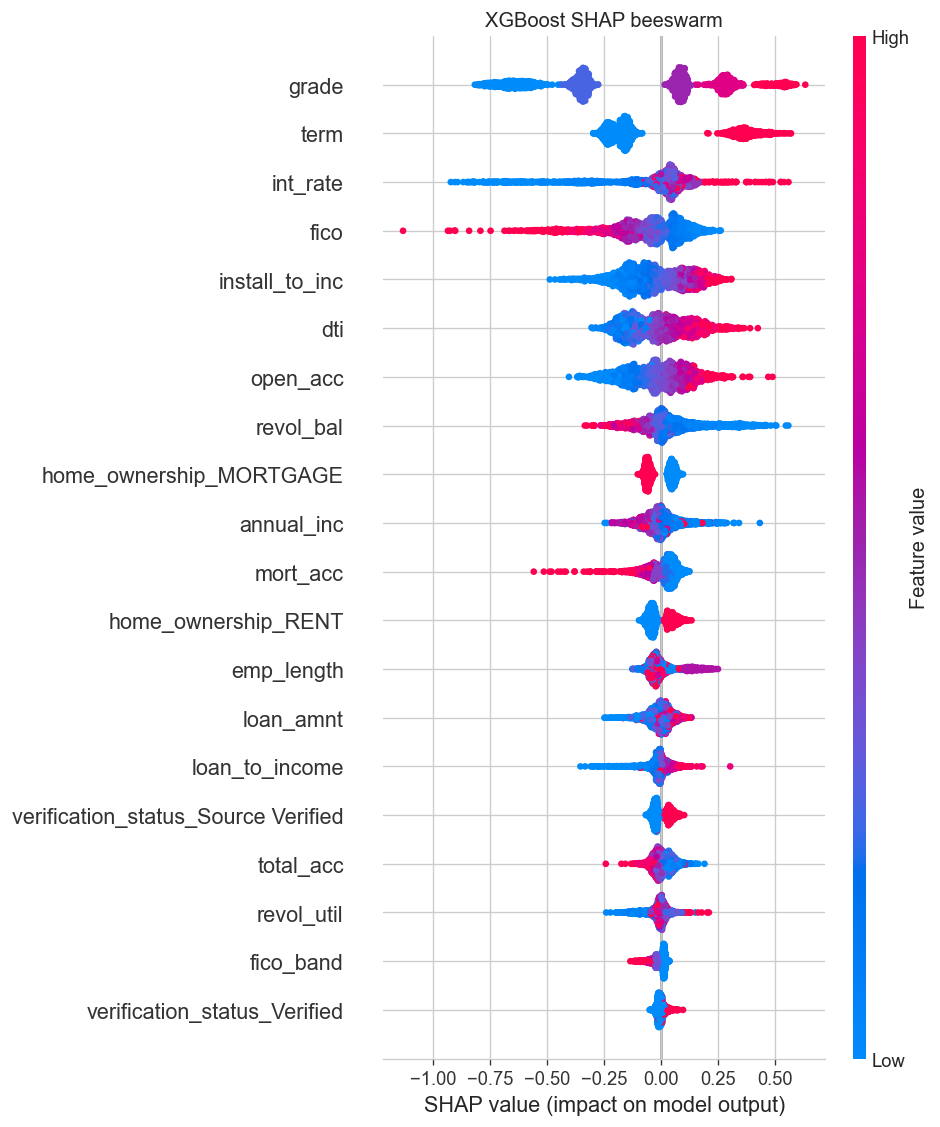

In [24]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:2000])

shap.summary_plot(shap_values, X_test[:2000], feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('XGBoost SHAP mean absolute values')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

shap.summary_plot(shap_values, X_test[:2000], feature_names=feature_names, show=False)
plt.title('XGBoost SHAP beeswarm')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Neural Network (MLP)

In [25]:
mlp_model, device = train_mlp(
    X_train, y_train, X_val, y_val,
    hidden_dims=(256, 128, 64), dropout=0.3,
    lr=1e-3, batch_size=512, epochs=50, patience=5,
)
scaled_mlp = calibrate_temperature(mlp_model, X_val, y_val, device)

y_prob_nn = nn_predict_proba(scaled_mlp, X_test, device)
print(pd.Series(evaluate(y_test, y_prob_nn, model_name='Neural Network')))

Early stopping at epoch 6
Optimal temperature: 1.0528
model        Neural Network
threshold               0.5
roc_auc              0.6986
pr_auc               0.3599
brier                0.2168
f1                   0.4362
precision            0.3282
recall               0.6499
dtype: object


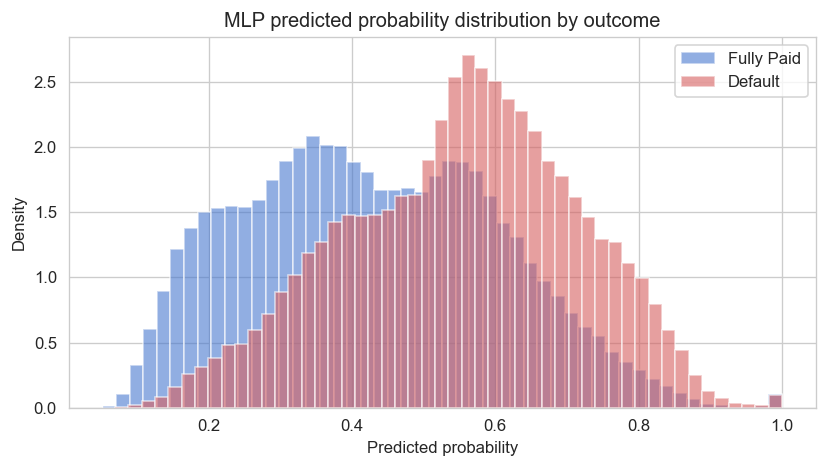

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_prob_nn[y_test==0], bins=50, alpha=0.6, label='Fully Paid', density=True, color='#4878CF')
ax.hist(y_prob_nn[y_test==1], bins=50, alpha=0.6, label='Default',    density=True, color='#D65F5F')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.set_title('MLP predicted probability distribution by outcome')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/nn_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Calibration Evaluation

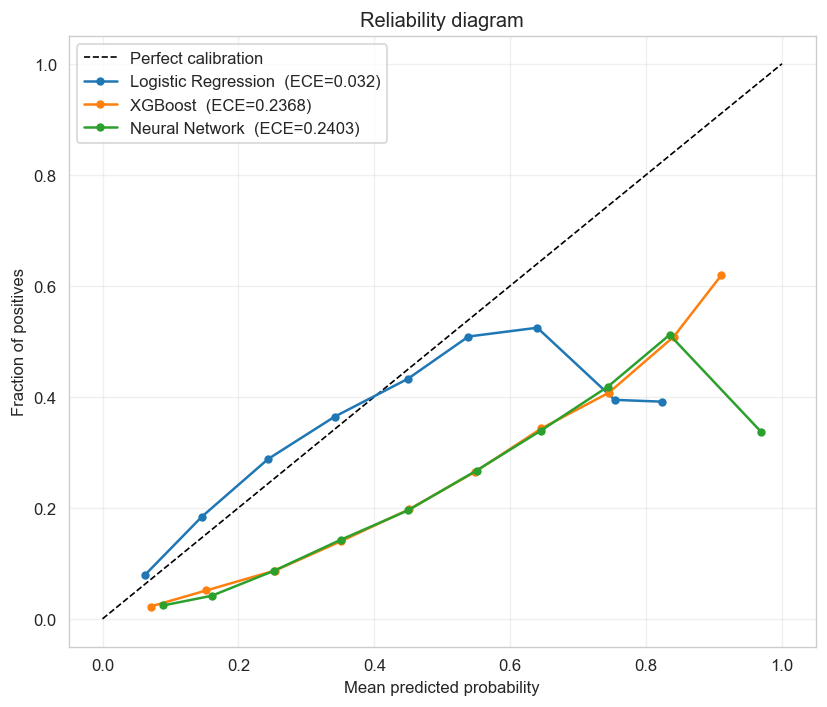

In [27]:
all_models = {
    'Logistic Regression': y_prob_lr,
    'XGBoost':             y_prob_xgb,
    'Neural Network':      y_prob_nn,
}

# Reliability diagram
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', lw=1, label='Perfect calibration')
for name, prob in all_models.items():
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    ece = expected_calibration_error(y_test, prob)
    ax.plot(mean_pred, frac_pos, marker='o', markersize=4, label=f'{name}  (ECE={ece})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability diagram')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/calibration_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

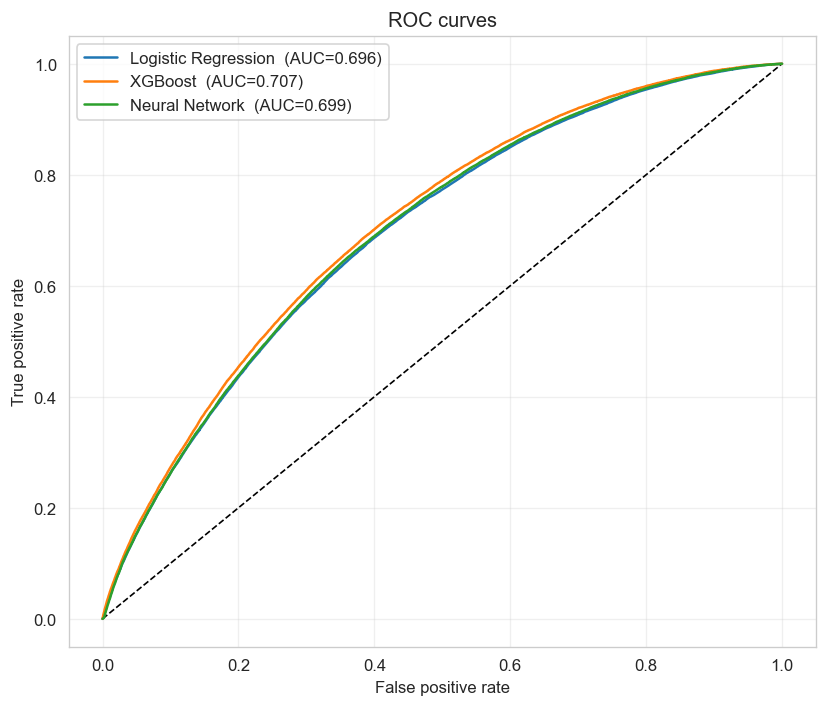

In [28]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1], [0,1], 'k--', lw=1)
for name, prob in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={roc_auc_score(y_test, prob):.3f})')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Model comparison table
rows = []
for name, prob in all_models.items():
    row = evaluate(y_test, prob, model_name=name)
    row['ece'] = expected_calibration_error(y_test, prob)
    rows.append(row)

comparison = pd.DataFrame(rows)[['model','roc_auc','pr_auc','brier','ece','f1','precision','recall']]
print(comparison.to_string(index=False))
comparison.to_csv('../reports/model_comparison.csv', index=False)

              model  roc_auc  pr_auc  brier    ece     f1  precision  recall
Logistic Regression   0.6958  0.3607 0.1557 0.0320 0.0959     0.4978  0.0531
            XGBoost   0.7074  0.3775 0.2141 0.2368 0.4412     0.3340  0.6495
     Neural Network   0.6986  0.3599 0.2168 0.2403 0.4362     0.3282  0.6499


---
## 12. Threshold Optimization

In [30]:
sweep_df = threshold_sweep(y_test, y_prob_xgb)
ops      = find_operating_points(sweep_df)

print('Operating points:')
for label, row in ops.items():
    print(f"  {label}: threshold={row['threshold']:.3f}  "
          f"precision={row['precision']:.3f}  "
          f"recall={row['recall']:.3f}  "
          f"f1={row['f1']:.3f}")

Operating points:
  F1-optimal: threshold=0.483  precision=0.326  recall=0.685  f1=0.442
  Conservative: threshold=0.948  precision=1.000  recall=0.000  f1=0.000


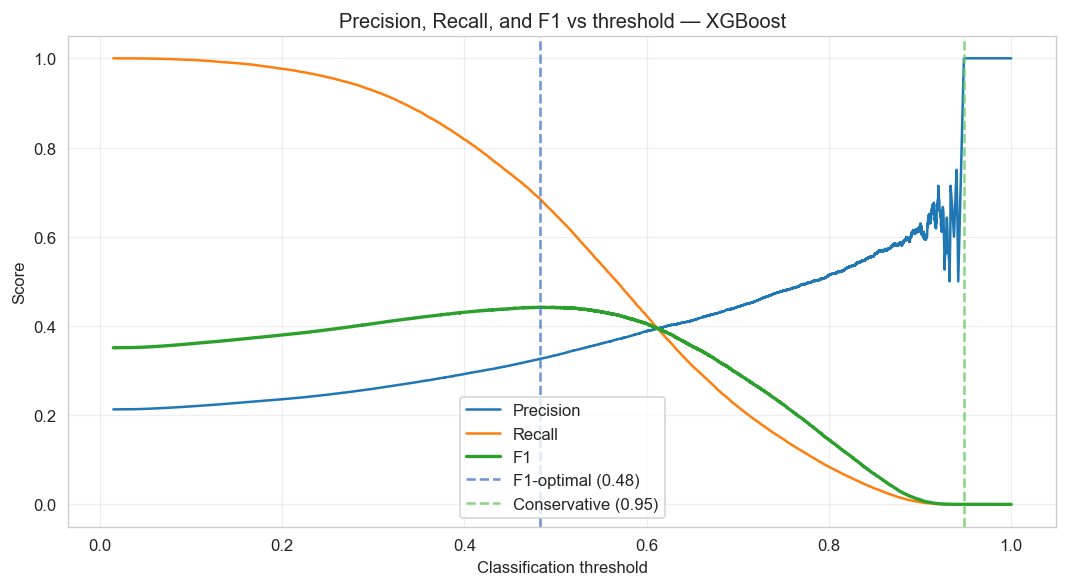

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision')
ax.plot(sweep_df['threshold'], sweep_df['recall'],    label='Recall')
ax.plot(sweep_df['threshold'], sweep_df['f1'],        label='F1', lw=2)
colors_ops = {'F1-optimal': '#4878CF', 'Conservative': '#6ACC65'}
for label, row in ops.items():
    ax.axvline(row['threshold'], linestyle='--', alpha=0.8,
               color=colors_ops[label], label=f"{label} ({row['threshold']:.2f})")
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 vs threshold — XGBoost')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Fairness Evaluation

In [32]:
# Income tercile grouping using raw (unscaled) annual_inc from the test split
income_group = pd.qcut(
    pd.Series(annual_inc_test), q=3,
    labels=['Low income', 'Mid income', 'High income']
)
print('Income group distribution:')
print(income_group.value_counts())

Income group distribution:
Mid income     76054
Low income     75249
High income    74336
Name: count, dtype: int64


In [33]:
t_f1   = ops['F1-optimal']['threshold']
t_cons = ops['Conservative']['threshold']

for label, t in [('F1-optimal', t_f1), ('Conservative', t_cons)]:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    mf = MetricFrame(
        metrics={
            'accuracy':            accuracy_score,
            'false_positive_rate': false_positive_rate,
            'true_positive_rate':  true_positive_rate,
            'selection_rate':      selection_rate,
        },
        y_true=y_test, y_pred=y_pred_t,
        sensitive_features=income_group,
    )
    by_group = mf.by_group.copy()
    by_group['fpr_gap'] = by_group['false_positive_rate'] - by_group['false_positive_rate'].min()
    print(f'\n--- {label} (t={t:.3f}) ---')
    print(by_group.round(4).to_string())
    fpr_vals = mf.by_group['false_positive_rate']
    tpr_vals = mf.by_group['true_positive_rate']
    print(f'FPR gap: {fpr_vals.max()-fpr_vals.min():.4f}  |  TPR gap: {tpr_vals.max()-tpr_vals.min():.4f}')


--- F1-optimal (t=0.483) ---
                     accuracy  false_positive_rate  true_positive_rate  selection_rate  fpr_gap
sensitive_feature_0                                                                            
High income            0.6814               0.3033              0.6134          0.3604   0.0000
Low income             0.5840               0.4662              0.7386          0.5330   0.1630
Mid income             0.6300               0.3846              0.6852          0.4474   0.0813
FPR gap: 0.1630  |  TPR gap: 0.1253

--- Conservative (t=0.948) ---
                     accuracy  false_positive_rate  true_positive_rate  selection_rate  fpr_gap
sensitive_feature_0                                                                            
High income            0.8156                  0.0              0.0000             0.0      0.0
Low income             0.7548                  0.0              0.0000             0.0      0.0
Mid income             0.7911         

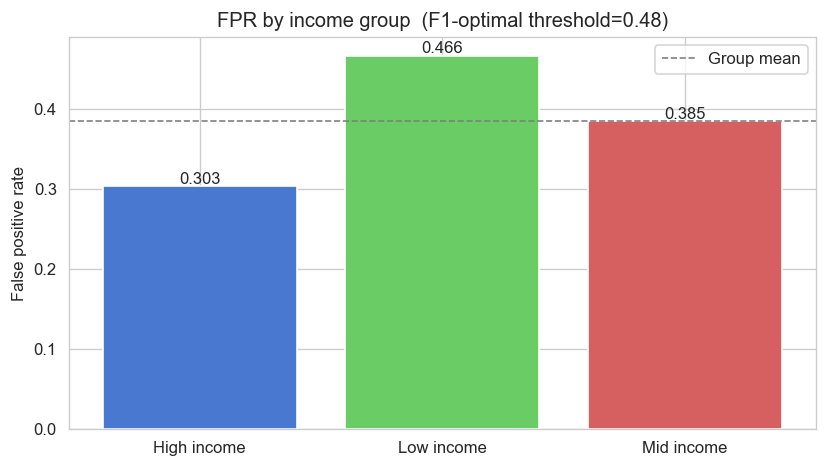

In [34]:
# FPR by income group at F1-optimal threshold
y_pred_f1 = (y_prob_xgb >= t_f1).astype(int)
mf_f1 = MetricFrame(
    metrics={'false_positive_rate': false_positive_rate},
    y_true=y_test, y_pred=y_pred_f1,
    sensitive_features=income_group,
)
groups = mf_f1.by_group['false_positive_rate']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(groups.index, groups.values, color=['#4878CF', '#6ACC65', '#D65F5F'])
ax.axhline(groups.mean(), linestyle='--', color='gray', lw=1, label='Group mean')
ax.set_ylabel('False positive rate')
ax.set_title(f'FPR by income group  (F1-optimal threshold={t_f1:.2f})')
for bar, val in zip(bars, groups.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.3f}', ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/fairness_fpr_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

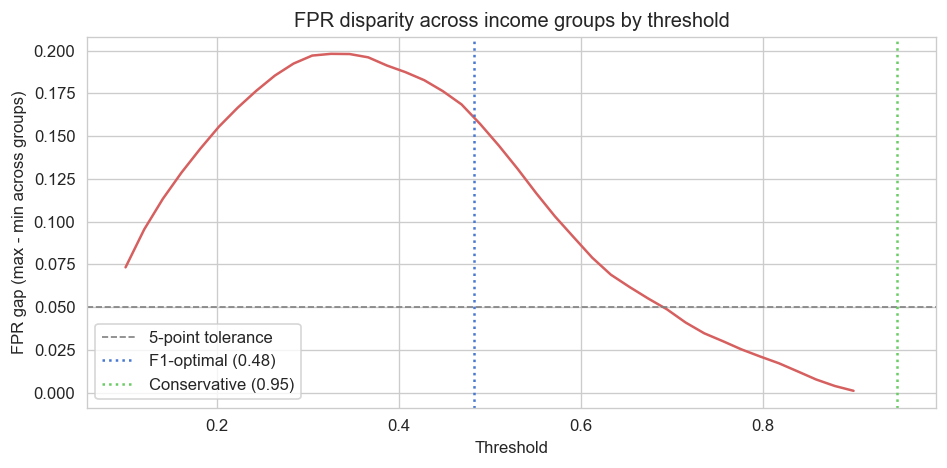

In [35]:
# FPR gap across all thresholds
# FIX: guard against division by zero when a group has no true negatives at extreme thresholds
group_labels = income_group.cat.categories.tolist()
group_arr    = income_group.values
thresholds   = np.linspace(0.1, 0.9, 40)
fpr_gaps     = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    fprs = []
    for g in group_labels:
        mask = group_arr == g
        # Skip group if no true negatives exist (FPR undefined)
        if (y_test[mask] == 0).sum() == 0:
            continue
        fprs.append(false_positive_rate(y_test[mask], y_pred_t[mask]))
    fpr_gaps.append(max(fprs) - min(fprs) if len(fprs) > 1 else 0.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, fpr_gaps, color='#D65F5F')
ax.axhline(0.05, linestyle='--', color='gray', lw=1, label='5-point tolerance')
ax.axvline(t_f1,   linestyle=':', color='#4878CF', lw=1.5, label=f'F1-optimal ({t_f1:.2f})')
ax.axvline(t_cons, linestyle=':', color='#6ACC65', lw=1.5, label=f'Conservative ({t_cons:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('FPR gap (max - min across groups)')
ax.set_title('FPR disparity across income groups by threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/fairness_fpr_gap.png', dpi=150, bbox_inches='tight')
plt.show()